# 레짐-패턴실험 2026.03.17

재설계한 레짐 체계 기준으로, 지금까지 검증한 패턴 실험을 레짐별로 정리한다.


## 메모

- 이 노트북은 레짐별 대표 패턴 1개를 먼저 보고, 그 아래 `실험` 섹션에서 후보군을 비교하는 구조로 정리했다.
- `benchmark`는 같은 레짐 안의 전체 종목 패턴이다.
- `Backtest(..., regime=...)`를 사용하면 `analyze()`에 넣는 패턴과 benchmark에 기본 레짐이 자동으로 붙는다.
- `Pattern Frequency (%)`는 각 패턴의 발생 빈도를 같은 레짐 benchmark 대비 비율로 그린 차트다.
- `bt.plot_wealth_curves()`는 마지막 `analyze()` 결과 전체를 자산곡선으로 그리고, 바로 아래에 성과 요약 테이블을 보여준다.
- WSL 메모리 부담을 줄이기 위해 필요한 섹션만 골라 실행하는 것을 권장한다.


In [1]:
%reload_ext autoreload
%autoreload 2

import pandas as pd

from src.backtest import Backtest, Univ
from src.pattern import (
    Pattern,
    Bollinger,
    High,
    Trending,
    MFI,
    RelativeStrength,
    AmountSurge,
    RetestBreakout,
    Disparity,
    PanicRebound,
)
from src.regime import Regime

pd.options.display.float_format = '{:.4f}'.format

start = "2000-01-01"
end = "2025-12-31"
univ = Univ(market=["KOSPI", "KOSDAQ"])
benchmark = Pattern(name="benchmark")

## `trend_friendly`

현재 실전 주력 레짐이다. 지금까지 검증한 조합 중에서는 `볼린저돌파 + 52주 고가 + MA200 상향 + MFI > 50 + AmountSurge(20, 1.5x)`가 가장 실전적인 기준선이다.


### 대표 패턴

현재 기준 주력 조합만 먼저 본다. `trend_base`는 거래대금 필터 전 기준선이고, `trend_amount1.5x`가 대표 패턴이다.


benchmark | trim: 100%|██████████| 6409/6409 [00:02<00:00, 2916.47it/s]
trend_base | trim: 100%|██████████| 6409/6409 [00:00<00:00, 81069.58it/s]
trend_amount1.5x | trim: 100%|██████████| 6409/6409 [00:00<00:00, 83273.84it/s]
benchmark | run: 100%|██████████| 6408/6408 [00:01<00:00, 3472.23it/s]
trend_base | run: 100%|██████████| 6408/6408 [00:00<00:00, 16215.67it/s]
trend_amount1.5x | run: 100%|██████████| 6408/6408 [00:00<00:00, 16468.08it/s]


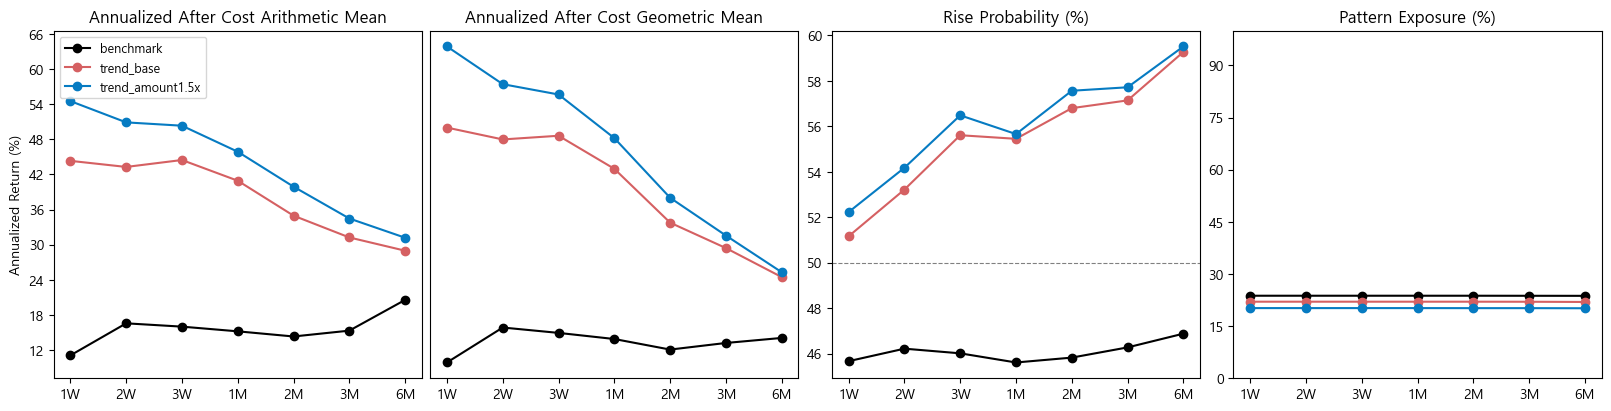

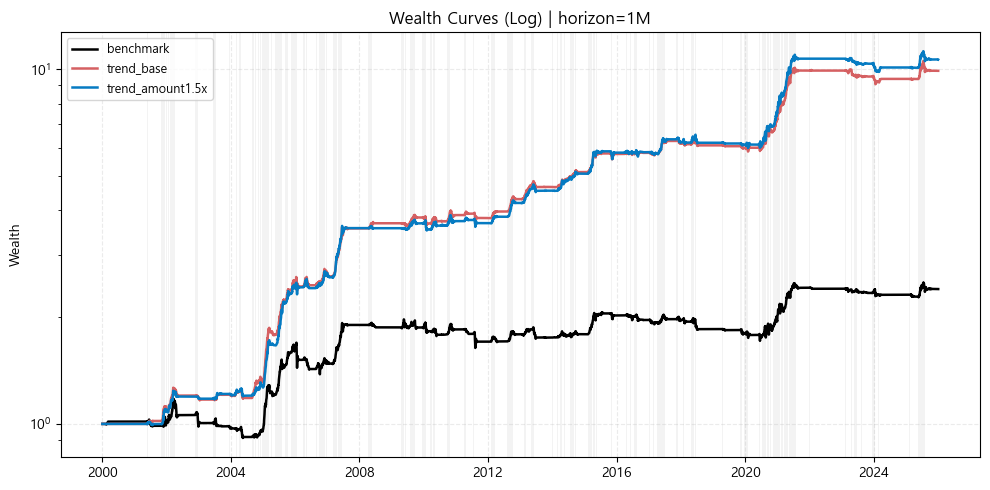

,total_return,final_wealth,cagr,mdd,ann_vol,ir,mean_exposure,cohort_win_rate,payoff_ratio,active_day_ratio,total_fee_paid
pattern,,,,,,,,,,,
benchmark,1.4001,2.4001,0.0343,-0.2232,0.0644,0.5319,0.2376,0.5726,1.3584,0.5126,0.3103
trend_base,8.8995,9.8995,0.0922,-0.1013,0.0557,1.6571,0.2213,0.6364,1.7444,0.5051,0.8076
trend_amount1.5x,9.6520,10.6520,0.0953,-0.1052,0.0569,1.6757,0.2033,0.6218,1.8936,0.4953,0.7847


In [2]:
regime = Regime().on(kind="trend_friendly", market="kospi")
bt = Backtest(start=start, end=end, by="day", benchmark=benchmark, univ=univ, regime=regime)

bb = Bollinger(name="볼린저돌파").on(
    trigger="breakout_up",
    breakout_cooldown_days=3,
    bandwidth_max=0.05,
)
high52w = High(name="52주 고가").on(window=240, threshold=0.90, stay_days=1)
uptrend = Trending(name="이평상향").on(trigger="ma_trend_up", window=200)
mfi_high = MFI(name="MFI상승").on(trigger="above", threshold=50)
amount15 = AmountSurge(name="amount1.5x").on(window=20, threshold=1.5)

base = (bb + high52w + uptrend + mfi_high).named("trend_base")
best = (bb + high52w + uptrend + mfi_high + amount15).named("trend_amount1.5x")

stats = bt.analyze(base, best)
stats.plot(annualized=True)
bt.plot_wealth_curves(target_horizon="1M", trade_price_mode="당일종가")

### 실험

아래는 `trend_friendly` 안에서 후보 필터를 비교한 과정이다. 결론적으로는 `AmountSurge(20, 1.5x)`가 가장 안정적인 quality filter였고, `RetestBreakout`은 second-entry 아이디어로는 의미가 있었지만 기준선을 넘지 못했다.


#### AmountSurge family

거래대금 품질 필터의 강도를 비교한다. 현재까지는 `1.5x`가 가장 균형이 좋고, `2.0x`는 표본을 더 줄이는 대신 개선이 일관적이지 않았다.


In [ ]:
regime = Regime().on(kind="trend_friendly", market="kospi")
bt = Backtest(start=start, end=end, by="day", benchmark=benchmark, univ=univ, regime=regime)

bb = Bollinger(name="볼린저돌파").on(
    trigger="breakout_up",
    breakout_cooldown_days=3,
    bandwidth_max=0.05,
)
high52w = High(name="52주 고가").on(window=240, threshold=0.90, stay_days=1)
uptrend = Trending(name="이평상향").on(trigger="ma_trend_up", window=200)
mfi_high = MFI(name="MFI상승").on(trigger="above", threshold=50)

base = (bb + high52w + uptrend + mfi_high).named("trend_amount_base")

amount15 = AmountSurge(name="amount1.5x").on(window=20, threshold=1.5)
amount20 = AmountSurge(name="amount2.0x").on(window=20, threshold=2.0)

pat_amount15 = (bb + high52w + uptrend + mfi_high + amount15).named("trend_amount1.5x")
pat_amount20 = (bb + high52w + uptrend + mfi_high + amount20).named("trend_amount2.0x")

stats = bt.analyze(base, pat_amount15, pat_amount20)
stats.plot(annualized=True)
bt.plot_wealth_curves(target_horizon="1M", trade_price_mode="당일종가")


#### RelativeStrength family

`RelativeStrength`는 시장 대비 초과성과 필터다. 추세 추종 품질을 더 올릴 수 있을지 봤지만, 현재까지는 `AmountSurge(20, 1.5x)`보다 우선순위가 낮다.


In [ ]:
regime = Regime().on(kind="trend_friendly", market="kospi")
bt = Backtest(start=start, end=end, by="day", benchmark=benchmark, univ=univ, regime=regime)

bb = Bollinger(name="볼린저돌파").on(
    trigger="breakout_up",
    breakout_cooldown_days=3,
    bandwidth_max=0.05,
)
high52w = High(name="52주 고가").on(window=240, threshold=0.90, stay_days=1)
uptrend = Trending(name="이평상향").on(trigger="ma_trend_up", window=200)
mfi_high = MFI(name="MFI상승").on(trigger="above", threshold=50)

base = (bb + high52w + uptrend + mfi_high).named("trend_rs_base")

rs60_0 = RelativeStrength(name="RS60>=0").on(market="kospi", window=60, threshold=0.0)
rs60_5 = RelativeStrength(name="RS60>=5%p").on(market="kospi", window=60, threshold=0.05)
rs120_0 = RelativeStrength(name="RS120>=0").on(market="kospi", window=120, threshold=0.0)

pat_rs60_0 = (bb + high52w + uptrend + mfi_high + rs60_0).named("trend_rs60>=0")
pat_rs60_5 = (bb + high52w + uptrend + mfi_high + rs60_5).named("trend_rs60>=5%p")
pat_rs120_0 = (bb + high52w + uptrend + mfi_high + rs120_0).named("trend_rs120>=0")

stats = bt.analyze(base, pat_rs60_0, pat_rs60_5, pat_rs120_0)
stats.plot(annualized=True)
bt.plot_wealth_curves(target_horizon="1M", trade_price_mode="당일종가")


#### RetestBreakout family

`RetestBreakout`은 고점 돌파 직후 추격하지 않고, 눌림 뒤 재상승에서 들어가는 second-entry 후보였다. benchmark 대비로는 의미가 있었지만 `trend_base`와 `trend_amount1.5x`를 넘지 못했다.


In [ ]:
regime = Regime().on(kind="trend_friendly", market="kospi")
bt = Backtest(start=start, end=end, by="day", benchmark=benchmark, univ=univ, regime=regime)

bb = Bollinger(name="볼린저돌파").on(
    trigger="breakout_up",
    breakout_cooldown_days=3,
    bandwidth_max=0.05,
)
high52w = High(name="52주 고가").on(window=240, threshold=0.90, stay_days=1)
uptrend = Trending(name="이평상향").on(trigger="ma_trend_up", window=200)
mfi_high = MFI(name="MFI상승").on(trigger="above", threshold=50)

base = (bb + high52w + uptrend + mfi_high).named("trend_retest_base")

retest = RetestBreakout(name="retest").on(
    breakout_window=20,
    retest_tolerance=0.03,
    max_retest_days=10,
    rebound_confirm="close_up",
)
retest_amount = RetestBreakout(name="retest+amount").on(
    breakout_window=20,
    retest_tolerance=0.03,
    max_retest_days=10,
    breakout_amount_threshold=1.5,
    breakout_amount_window=20,
    rebound_confirm="close_up",
)

pat_retest = (retest + high52w + uptrend + mfi_high).named("trend_retest")
pat_retest_amount = (retest_amount + high52w + uptrend + mfi_high).named("trend_retest+breakout_amount1.5x")

stats = bt.analyze(base, pat_retest, pat_retest_amount)
stats.plot(annualized=True)
bt.plot_wealth_curves(target_horizon="1M", trade_price_mode="당일종가")


## `contrarian_friendly`

재설계한 레짐 체계 안에 이 이름은 남겨두었지만, 아직 독립적으로 정리할 만한 검증 패턴은 충분하지 않다. 현재는 panic 구간 실험과 분리해서 후속 아이디어를 모으는 단계다.


## `panic_rebound_risk`

panic 구간은 기본적으로 패턴을 `off`로 두는 쪽이 우선이다. 다만 예외 후보를 기록할 필요가 있어서, 현재까지는 `MFI oversold_rebound`를 대표 후보로만 남겨둔다.


### 대표 패턴

`panic_mfi_oversold`는 panic 레짐에서 완전히 긍정적이라고 보긴 어렵지만, 현재까지 검증한 후보 중에서는 가장 덜 나쁜 예외 패턴이다.


In [ ]:
regime = Regime().on(kind="panic_rebound_risk", market="kospi")
bt = Backtest(start=start, end=end, by="day", benchmark=benchmark, univ=univ, regime=regime)

mfi = MFI(name="panic_mfi_oversold").on(
    trigger="oversold_rebound",
    lower=20,
    stay_days=1,
    cooldown_days=5,
).named("panic_mfi_oversold")

stats = bt.analyze(mfi)
stats.plot(annualized=True)
bt.plot_wealth_curves(target_horizon="1M", trade_price_mode="당일종가")


### 실험

아래는 panic 레짐에서 예외 전략을 만들 수 있는지 살펴본 과정이다. 결론은 `PanicRebound` 커스텀 패턴을 더 밀어붙이기보다는, 기본 `off` 정책을 유지하고 필요하면 `MFI oversold_rebound`만 보수적으로 검토하는 쪽이다.


#### PanicRebound vs 기존 후보

`Disparity`, `MFI oversold_rebound`, `PanicRebound`, `PanicRebound + volume spike`를 같이 비교한다.


In [ ]:
regime = Regime().on(kind="panic_rebound_risk", market="kospi")
bt = Backtest(start=start, end=end, by="day", benchmark=benchmark, univ=univ, regime=regime)

disparity = Disparity(name="panic_disparity0.9", window=20).on(
    threshold=0.9,
    stay_days=1,
    cooldown_days=5,
).named("panic_disparity0.9")

mfi = MFI(name="panic_mfi_oversold").on(
    trigger="oversold_rebound",
    lower=20,
    stay_days=1,
    cooldown_days=5,
).named("panic_mfi_oversold")

panic_plain = PanicRebound(name="panic_rebound").on(
    drawdown_window=20,
    drawdown_min=-0.18,
    rebound_days=3,
    volume_spike=False,
    volume_window=20,
    volume_threshold=1.5,
).named("panic_rebound")

panic_volume = PanicRebound(name="panic_rebound+volume1.5x").on(
    drawdown_window=20,
    drawdown_min=-0.18,
    rebound_days=3,
    volume_spike=True,
    volume_window=20,
    volume_threshold=1.5,
).named("panic_rebound+volume1.5x")

stats = bt.analyze(disparity, mfi, panic_plain, panic_volume)
stats.plot(annualized=True)
bt.plot_wealth_curves(target_horizon="1M", trade_price_mode="당일종가")


#### Quick check: `Bollinger near_down + MFI`

기존 재료 조합도 panic 레짐 안에서 같이 확인한다. 이 조합도 현재 기준으로는 대표 후보가 되지 못했다.


In [ ]:
regime = Regime().on(kind="panic_rebound_risk", market="kospi")
bt = Backtest(start=start, end=end, by="day", benchmark=benchmark, univ=univ, regime=regime)

disparity = Disparity(name="panic_disparity0.9_extra", window=20).on(
    threshold=0.9,
    stay_days=1,
    cooldown_days=5,
).named("panic_disparity0.9_extra")

mfi = MFI(name="panic_mfi_oversold_extra").on(
    trigger="oversold_rebound",
    lower=20,
    stay_days=1,
    cooldown_days=5,
).named("panic_mfi_oversold_extra")

bb_near_down = Bollinger(name="bb_near_down").on(
    trigger="near_down",
    bandwidth_max=1.0,
    near_tolerance=0.03,
    near_stay_days=1,
)
mfi_combo = MFI(name="mfi_oversold").on(
    trigger="oversold_rebound",
    lower=20,
    stay_days=1,
    cooldown_days=5,
)
combo = (bb_near_down + mfi_combo).named("panic_bb_near_down+mfi")

stats = bt.analyze(disparity, mfi, combo)
stats.plot(annualized=True)
bt.plot_wealth_curves(target_horizon="1M", trade_price_mode="당일종가")


## `neutral`

`neutral` 레짐은 아직 별도 패턴 실험 결과가 정리되지 않았다. 현재까지는 적극적으로 패턴을 켜기보다 관찰 구간에 가깝다.
